In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spandanpatnaik09/face-mask-detectormask-not-mask-incorrect-mask")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\indira kumar\.cache\kagglehub\datasets\spandanpatnaik09\face-mask-detectormask-not-mask-incorrect-mask\versions\1


In [7]:
import os



print("Dataset Contents:", os.listdir(path))  # List main folder contents


Dataset Contents: ['dataset']


In [8]:
dataset_path = os.path.join(path, "dataset")  # Full path to dataset folder

if os.path.exists(dataset_path):
    print("'dataset' folder found!")
    print("Contents:", os.listdir(dataset_path))  # List contents
else:
    print(" Error: 'dataset' folder is missing!")


'dataset' folder found!
Contents: ['incorrect_mask', 'without_mask', 'with_mask']


In [9]:
import os

dataset_path = "C:\\Users\\indira kumar\\.cache\\kagglehub\\datasets\\spandanpatnaik09\\face-mask-detectormask-not-mask-incorrect-mask\\versions\\1\\dataset"


# List all categories
categories = ["incorrect_mask", "without_mask", "with_mask"]

# Count images in each category
for category in categories:
    folder = os.path.join(dataset_path, category)
    num_images = len(os.listdir(folder))
    print(f" {category}: {num_images} images")


 incorrect_mask: 703 images
 without_mask: 686 images
 with_mask: 690 images


In [10]:
# Image parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [11]:
# Data Augmentation & Normalization
datagen = ImageDataGenerator(
    rescale=1.0/255,       # Normalize pixel values (0-1)
    validation_split=0.2,   # Split dataset into 80% train, 20% validation
    rotation_range=20,      # Augment data by rotating images
    zoom_range=0.2,
    horizontal_flip=True
)

In [12]:
# Load training images
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

Found 1664 images belonging to 3 classes.


In [13]:
# Load validation images
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

Found 415 images belonging to 3 classes.


In [14]:
# Check class labels
print("Class Labels:", train_data.class_indices)

Class Labels: {'incorrect_mask': 0, 'with_mask': 1, 'without_mask': 2}


In [15]:
#Build CNN Model
# ==========================
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),  # Prevent overfitting
    tf.keras.layers.Dense(3, activation="softmax")  # 3 output classes
])

c:\Users\indira kumar\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:

# Compile model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#Train CNN Model
# ==========================
EPOCHS = 20

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

c:\Users\indira kumar\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 39s 646ms/step - accuracy: 0.4438 - loss: 1.1238 - val_accuracy: 0.8169 - val_loss: 0.4918
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 545ms/step - accuracy: 0.8081 - loss: 0.4766 - val_accuracy: 0.8506 - val_loss: 0.3656
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 537ms/step - accuracy: 0.8517 - loss: 0.3869 - val_accuracy: 0.8795 - val_loss: 0.2949
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 537ms/step - accuracy: 0.8981 - loss: 0.2780 - val_accuracy: 0.9277 - val_loss: 0.2254
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 543ms/step - accuracy: 0.9282 - loss: 0.1954 - val_accuracy: 0.9277 - val_loss: 0.2025
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 545ms/step - accuracy: 0.9345 - loss: 0.1951 - val_accuracy: 0.9325 - val_loss: 0.1637
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 542ms/step - accuracy: 0.9402 - loss: 0.1868 - val_accuracy: 0.9277 - val_loss: 0.1896
Epoch 8/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 544ms/step - accuracy: 0.9266 - loss: 0.1847 - val_accu

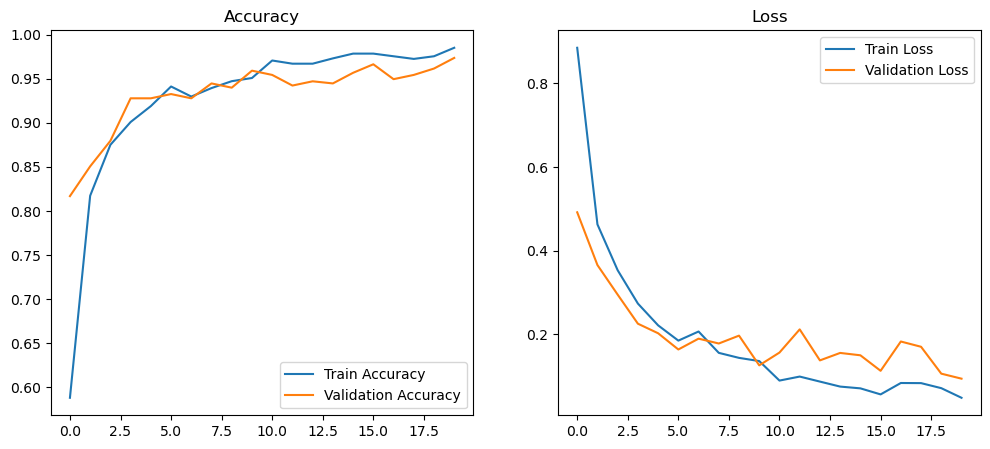

Model saved as 'mask_detector_model.h5'


In [18]:
# Plot Accuracy & Loss
# ==========================
plt.figure(figsize=(12,5))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

# ==========================
#  Save Model
# ==========================
model.save("mask_detector_model.h5")
print("Model saved as 'mask_detector_model.h5'")

In [19]:
# Save model in the new Keras format
model.save("mask_detector_model.keras")  # Saves as .keras


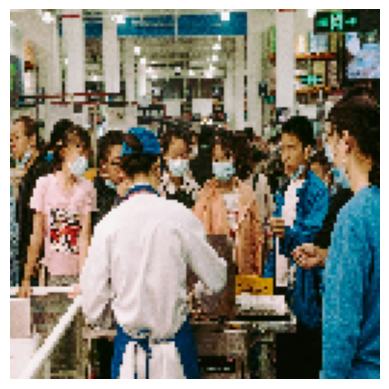

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load and preprocess image
img_path = "C:\\Users\indira kumar\Downloads\\joshua-fernandez-UX4ljKzOBVw-unsplash.jpg"  # Replace with your image path
img = image.load_img(img_path, target_size=(128, 128))  # Resize to match model input
img_array = image.img_to_array(img)  
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array /= 255.0  # Normalize (0-1)

# Display the image
plt.imshow(img)
plt.axis("off")
plt.show()


In [21]:
# Predict
predictions = model.predict(img_array)

# Class labels (adjust based on your dataset)
class_labels = {0: "Incorrect Mask", 1: "Without Mask", 2: "With Mask"}
predicted_class = np.argmax(predictions)

print(f" Prediction: {class_labels[predicted_class]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
 Prediction: Incorrect Mask


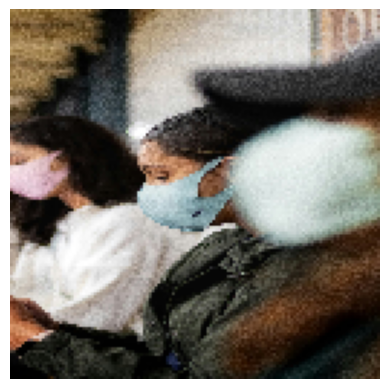

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load and preprocess image
img_path = "C:\\Users\indira kumar\Downloads\\brian-asare-z7lTC8cFKKs-unsplash.jpg"  # Replace with your image path
img = image.load_img(img_path, target_size=(128, 128))  # Resize to match model input
img_array = image.img_to_array(img)  
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array /= 255.0  # Normalize (0-1)

# Display the image
plt.imshow(img)
plt.axis("off")
plt.show()

In [23]:
# Predict
predictions = model.predict(img_array)

# Class labels (adjust based on your dataset)
class_labels = {0: "Incorrect Mask", 1: "Without Mask", 2: "With Mask"}
predicted_class = np.argmax(predictions)

print(f" Prediction: {class_labels[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
 Prediction: Without Mask


In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the trained model
model = keras.models.load_model("mask_detector_model.keras")

# Define dataset path
dataset_path = "C:\\Users\\indira kumar\\.cache\\kagglehub\\datasets\\spandanpatnaik09\\face-mask-detectormask-not-mask-incorrect-mask\\versions\\1\\dataset"


c:\Users\indira kumar\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [25]:
datagen = ImageDataGenerator(
    rescale=1./255,  
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)


Found 1664 images belonging to 3 classes.
Found 415 images belonging to 3 classes.


In [26]:
print(model.input_shape)  # Should return something like (None, 150, 150, 3) or (None, 224, 224, 3)


(None, 128, 128, 3)


In [27]:
target_size = (128, 128)  # Match model's expected input size

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=target_size,  
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=target_size,  
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)


Found 1664 images belonging to 3 classes.
Found 415 images belonging to 3 classes.


In [28]:
from tensorflow.keras.layers import Flatten, Dense

model = keras.Sequential([
    model,  # Add original model
    Flatten(),  # Ensure input shape is 1D before fully connected layers
    Dense(128, activation="relu"),
    Dense(3, activation="softmax")  # Adjust based on class count
])


In [32]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [39]:
loss, accuracy = model.evaluate(val_generator)
print(f" Fine-tuned Model Accuracy: {accuracy:.2f},")


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 336ms/step - accuracy: 0.6015 - loss: 1.0712
 Fine-tuned Model Accuracy: 0.59,
